# E-Commerce Sales Analysis — Python 
### Indian E-Commerce Dataset  | 2022–2024

**Topics Covered:** Python Core · Intermediate Python · NumPy · Pandas · Matplotlib · Seaborn  
**Dataset:** `ecommerce_sales.csv` 
---
## Project Overview
This  project simulates a real-world data analytics workflow using an Indian e-commerce sales dataset.  
You will clean, explore, analyse, and visualise data to extract actionable business insights.

### Learning Objectives
| Module | Skills |
|--------|--------|
| 1. Setup & Loading | File I/O, Python basics, pandas basics |
| 2. Data Inspection | dtypes, shape, head/tail, info |
| 3. Data Cleaning | Missing values, type casting, duplicates |
| 4. Python Core & Intermediate | List comprehensions, lambda, map/filter, OOP |
| 5. NumPy | Arrays, vectorised ops, stats |
| 6. Pandas EDA | GroupBy, pivot, merge, resample |
| 7. Matplotlib | Line, bar, pie, scatter, subplots |
| 8. Seaborn | Heatmap, boxplot, violin, pairplot |
| 9. Business Insights | KPIs, cohort analysis, summary |
| 10. GitHub Push | Git workflow |


### Setup & Data Loading

In [ ]:
# !pip install pandas numpy matplotlib seaborn 

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 110
plt.rcParams['font.size'] = 11

In [ ]:
# ── Load the dataset ──────────────────────────────────────
df = pd.read_csv('ecommerce_sales.csv')
print(f"Dataset loaded: {df.shape[0]:,} rows × {df.shape[1]} columns")
df.head()

Dataset loaded: 10,000 rows × 17 columns


,order_id,customer_id,order_date,order_time,customer_age,customer_gender,customer_city,city_tier,category,product_name,unit_price,quantity,discount_pct,total_price,payment_method,order_status,rating
0,ORD100000,CUST8270,2022-01-01,05:55:41,36.0,Male,Pune,2,Clothing,Jeans,1849.11,1,10.0,1664.20,UPI,Delivered,4.0
1,ORD100001,CUST8603,2022-01-01,23:22:22,42.0,Male,Kolkata,1,Home & Kitchen,Mixer Grinder,10283.66,1,0.0,10283.66,Credit Card,Returned,NaN
2,ORD100002,CUST1860,2022-01-01,18:07:33,20.0,Male,Pune,2,Electronics,Smart Watch,71075.81,4,0.0,284303.24,UPI,Delivered,4.0
3,ORD100003,CUST6390,2022-01-02,02:53:21,18.0,Male,Chennai,1,Clothing,Saree,3112.82,1,10.0,2801.54,UPI,Delivered,5.0
4,ORD100004,CUST6226,2022-01-01,19:45:59,33.0,Female,Lucknow,2,Books,Self-Help,1426.37,1,10.0,1283.73,Debit Card,Delivered,5.0


### Data Inspection

In [ ]:
# Shape, dtypes, basic info
print("Shape :", df.shape)
print("\nColumn dtypes:")
print(df.dtypes)

Shape : (10000, 17)

Column dtypes:
order_id            object
customer_id         object
order_date          object
order_time          object
customer_age       float64
customer_gender     object
customer_city       object
city_tier            int64
category            object
product_name        object
unit_price         float64
quantity             int64
discount_pct       float64
total_price        float64
payment_method      object
order_status        object
rating             float64
dtype: object


In [ ]:
# Statistical summary
df.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
order_id,10000,10000,ORD100000,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
customer_id,10000,5635,CUST5780,8,NaN,NaN,NaN,NaN,NaN,NaN,NaN
order_date,10000,1096,2022-02-02,15,NaN,NaN,NaN,NaN,NaN,NaN,NaN
order_time,10000,9434,17:36:47,3,NaN,NaN,NaN,NaN,NaN,NaN,NaN
customer_age,9900.0,NaN,NaN,NaN,31.891212,9.253683,18.0,25.0,31.0,38.0,65.0
customer_gender,9900,3,Male,5173,NaN,NaN,NaN,NaN,NaN,NaN,NaN
customer_city,10000,10,Kolkata,1052,NaN,NaN,NaN,NaN,NaN,NaN,NaN
city_tier,10000.0,NaN,NaN,NaN,1.4093,0.491729,1.0,1.0,1.0,2.0,2.0
category,10000,8,Electronics,1948,NaN,NaN,NaN,NaN,NaN,NaN,NaN
product_name,10000,52,Pressure Cooker,267,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
# Missing value audit
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({'Missing Count': missing, 'Missing %': missing_pct})
print(missing_df[missing_df['Missing Count'] > 0])

                 Missing Count  Missing %
customer_age               100       1.00
customer_gender            100       1.00
discount_pct                80       0.80
rating                    2842      28.42


In [ ]:
# Unique values for categorical columns
cat_cols = df.select_dtypes(include='object').columns
for col in cat_cols:
    print(f"{col:20s}: {df[col].nunique()} unique values → {df[col].dropna().unique()[:5]}")
# 20s ==> 20 spaces

order_id            : 10000 unique values → ['ORD100000' 'ORD100001' 'ORD100002' 'ORD100003' 'ORD100004']
customer_id         : 5635 unique values → ['CUST8270' 'CUST8603' 'CUST1860' 'CUST6390' 'CUST6226']
order_date          : 1096 unique values → ['2022-01-01' '2022-01-02' '2022-01-03' '2022-01-04' '2022-01-05']
order_time          : 9434 unique values → ['05:55:41' '23:22:22' '18:07:33' '02:53:21' '19:45:59']
customer_gender     : 3 unique values → ['Male' 'Female' 'Other']
customer_city       : 10 unique values → ['Pune' 'Kolkata' 'Chennai' 'Lucknow' 'Ahmedabad']
category            : 8 unique values → ['Clothing' 'Home & Kitchen' 'Electronics' 'Books' 'Toys']
product_name        : 52 unique values → ['Jeans' 'Mixer Grinder' 'Smart Watch' 'Saree' 'Self-Help']
payment_method      : 6 unique values → ['UPI' 'Credit Card' 'Debit Card' 'EMI' 'Net Banking']
order_status        : 4 unique values → ['Delivered' 'Returned' 'Cancelled' 'Processing']


###  Data Cleaning

In [ ]:
# ──  Fix data types ───────────────────────────────────
df['order_date'] = pd.to_datetime(df['order_date'])
df['customer_age'] = df['customer_age'].fillna(df['customer_age'].median())
df['customer_gender'] = df['customer_gender'].fillna('Unknown')
df['discount_pct'] = df['discount_pct'].fillna(0)

print(" Types fixed")
print(df[['order_date','customer_age','customer_gender','discount_pct']].dtypes)


 Types fixed
order_date         datetime64[ns]
customer_age              float64
customer_gender            object
discount_pct              float64
dtype: object


In [ ]:
# ──  Add derived date columns ─────────────────────────
df['year']    = df['order_date'].dt.year
df['month']   = df['order_date'].dt.month
df['quarter'] = df['order_date'].dt.quarter
df['day_of_week'] = df['order_date'].dt.day_name()

print(" Date columns added")
df[['order_date','year','month','quarter','day_of_week']].head()

 Date columns added


,order_date,year,month,quarter,day_of_week
0,2022-01-01,2022,1,1,Saturday
1,2022-01-01,2022,1,1,Saturday
2,2022-01-01,2022,1,1,Saturday
3,2022-01-02,2022,1,1,Sunday
4,2022-01-01,2022,1,1,Saturday


In [ ]:
# ──  Duplicate check ──────────────────────────────────
dups = df.duplicated(subset='order_id').sum()
print(f"Duplicate order IDs: {dups}")
df = df.drop_duplicates(subset='order_id')
print(f"Dataset after dedup: {df.shape}")

Duplicate order IDs: 0
Dataset after dedup: (10000, 23)


In [ ]:
# ──  Validate numeric ranges ──────────────────────────
print("unit_price   :", df['unit_price'].min(), "–", df['unit_price'].max())
print("quantity     :", df['quantity'].min(), "–", df['quantity'].max())
print("discount_pct :", df['discount_pct'].min(), "–", df['discount_pct'].max())
print("total_price  :", df['total_price'].min(), "–", df['total_price'].max())
print("\nOrder status counts:")
print(df['order_status'].value_counts())

unit_price   : 49.9 – 79953.15
quantity     : 1 – 5
discount_pct : 0.0 – 30.0
total_price  : 35.17 – 396360.2

Order status counts:
order_status
Delivered     7158
Returned      1059
Cancelled     1029
Processing     754
Name: count, dtype: int64


## Python Core & Intermediate

###  List Comprehensions & Lambda Functions

In [ ]:
# List comprehension — classify age groups
df['age_group'] = ['Senior' if a >= 50 else 'Adult' if a >= 30 else 'Young Adult'
                   for a in df['customer_age']]

print(df['age_group'].value_counts())

age_group
Adult          5472
Young Adult    4176
Senior          352
Name: count, dtype: int64


In [ ]:
# Lambda + map — revenue tier
classify_revenue = lambda x: 'High' if x >= 10000 else ('Medium' if x >= 2000 else 'Low')
df['revenue_tier'] = df['total_price'].map(classify_revenue)
print(df['revenue_tier'].value_counts())

revenue_tier
Medium    3715
High      3703
Low       2582
Name: count, dtype: int64


###  Filter & Reduce

In [ ]:
from functools import reduce

# filter() — high value delivered orders
high_value = list(filter(lambda x: x > 20000, df['total_price'].tolist()))
print(f"Orders above ₹20,000: {len(high_value):,}")

# reduce() — cumulative sum of top-5 cities revenue
top5_rev = (df.groupby('customer_city')['total_price'].sum()
              .nlargest(5).tolist())
cumulative = reduce(lambda a, b: a + b, top5_rev)
print(f"\nTop-5 cities cumulative revenue: ₹{cumulative:.2f}")


Orders above ₹20,000: 2,486

Top-5 cities cumulative revenue: ₹129528130.42


###  OOP — Order Analytics Class

In [ ]:
class OrderAnalytics:
    """Encapsulates common order-level analytics."""

    def __init__(self, dataframe):
        self.df = dataframe.copy()

    def total_revenue(self, status='Delivered'):
        subset = self.df[self.df['order_status'] == status]
        return subset['total_price'].sum()

    def avg_order_value(self):
        return self.df['total_price'].mean()

    def top_categories(self, n=3):
        return (self.df.groupby('category')['total_price']
                       .sum().nlargest(n))

    def conversion_rate(self):
        """% of orders that were delivered."""
        delivered = (self.df['order_status'] == 'Delivered').sum()
        return round(delivered / len(self.df) * 100, 2)

    def summary(self):
        print("=" * 45)
        print("       E-Commerce Analytics Summary")
        print("=" * 45)
        print(f"  Total Orders       : {len(self.df):,}")
        print(f"  Total Revenue      : ₹{self.total_revenue():,.0f}")
        print(f"  Avg Order Value    : ₹{self.avg_order_value():,.2f}")
        print(f"  Delivery Rate      : {self.conversion_rate()}%")
        print("\n  Top 3 Categories by Revenue:")
        for cat, rev in self.top_categories().items():
            print(f"    {cat:<20} ₹{rev:>12,.0f}")
        print("=" * 45)

analytics = OrderAnalytics(df)
analytics.summary()

       E-Commerce Analytics Summary
  Total Orders       : 10,000
  Total Revenue      : ₹174,728,706
  Avg Order Value    : ₹24,371.36
  Delivery Rate      : 71.58%

  Top 3 Categories by Revenue:
    Electronics          ₹ 183,469,618
    Home & Kitchen       ₹  25,448,900
    Sports               ₹  13,538,380


##   NumPy Operations

In [ ]:
# ──  Create NumPy arrays from DataFrame columns ───────
prices    = np.array(df['unit_price'])
quantities = np.array(df['quantity'])
discounts = np.array(df['discount_pct'])
totals    = np.array(df['total_price'])

print("Shape  :", prices.shape)
print("Dtype  :", prices.dtype)

Shape  : (10000,)
Dtype  : float64


In [ ]:
# ──  Vectorised calculations ─────────────────────────
# Revenue after discount (vectorised — no Python loop)
calculated_totals = (prices * quantities * (1 - discounts / 100)).round(2)

# Check accuracy (should be ~0 mean error)
diff = np.abs(calculated_totals - totals)
print(f"Max difference from stored total_price: ₹{diff.max():.4f}")
print(f"Mean difference: ₹{diff.mean():.4f}")

Max difference from stored total_price: ₹23890.8200
Mean difference: ₹17.9701


In [ ]:
# ──  Descriptive statistics with NumPy ────────────────
print("Revenue Statistics (NumPy)")
print("-" * 35)
stats = {
    'Mean'        : np.mean(totals),
    'Median'      : np.median(totals),
    'Std Dev'     : np.std(totals),
    'Variance'    : np.var(totals),
    'Min'         : np.min(totals),
    'Max'         : np.max(totals),
    '25th pct'    : np.percentile(totals, 25),
    '75th pct'    : np.percentile(totals, 75),
    'IQR'         : np.percentile(totals, 75) - np.percentile(totals, 25),
}
for k, v in stats.items():
    print(f"  {k:<14}: ₹{v:>12,.2f}")


Revenue Statistics (NumPy)
-----------------------------------
  Mean          : ₹   24,371.36
  Median        : ₹    5,686.90
  Std Dev       : ₹   49,724.61
  Variance      : ₹2,472,536,716.92
  Min           : ₹       35.17
  Max           : ₹  396,360.20
  25th pct      : ₹    1,921.87
  75th pct      : ₹   19,850.99
  IQR           : ₹   17,929.13


In [ ]:
# ──  NumPy boolean indexing & masking ────────────────
high_value_mask  = totals > np.percentile(totals, 90)
print(f"Top 10% orders (> ₹{np.percentile(totals,90):,.0f}): {high_value_mask.sum():,}")
print(f"Revenue from top 10%: ₹{totals[high_value_mask].sum():,.0f}")
print(f"Revenue share: {totals[high_value_mask].sum()/totals.sum()*100:.1f}%")

Top 10% orders (> ₹64,508): 1,000
Revenue from top 10%: ₹148,487,697
Revenue share: 60.9%


In [ ]:
# ── Correlation matrix with NumPy ────────────────────
numeric_cols = ['unit_price', 'quantity', 'discount_pct', 'total_price', 'customer_age']
numeric_matrix = np.column_stack([df[c] for c in numeric_cols])
corr_matrix = np.corrcoef(numeric_matrix.T)

print("Correlation Matrix (NumPy):")
print(pd.DataFrame(corr_matrix, index=numeric_cols, columns=numeric_cols).round(3))

Correlation Matrix (NumPy):
              unit_price  quantity  discount_pct  total_price  customer_age
unit_price         1.000    -0.003        -0.008        0.810         0.007
quantity          -0.003     1.000         0.005        0.294         0.006
discount_pct      -0.008     0.005         1.000       -0.056        -0.002
total_price        0.810     0.294        -0.056        1.000        -0.000
customer_age       0.007     0.006        -0.002       -0.000         1.000


##  Pandas EDA

###  GroupBy Aggregations

In [ ]:
# Revenue and order count by category
cat_stats = (df.groupby('category')
               .agg(
                   total_orders=('order_id','count'),
                   total_revenue=('total_price','sum'),
                   avg_order_value=('total_price','mean'),
                   avg_discount=('discount_pct','mean'),
                   avg_rating=('rating','mean')
               )
               .sort_values('total_revenue', ascending=False)
               .round(2))

cat_stats['revenue_share_%'] = (cat_stats['total_revenue'] /
                                 cat_stats['total_revenue'].sum() * 100).round(2)
cat_stats

,total_orders,total_revenue,avg_order_value,avg_discount,avg_rating,revenue_share_%
category,,,,,,
Electronics,1948,1.834696e+08,94183.58,8.30,3.96,75.28
Home & Kitchen,1517,2.544890e+07,16775.81,8.84,3.99,10.44
Sports,1022,1.353838e+07,13246.95,8.39,3.92,5.56
Clothing,1740,1.044903e+07,6005.19,8.29,4.02,4.29
Toys,822,4.510942e+06,5487.76,9.00,3.97,1.85
Beauty,1008,3.353698e+06,3327.08,8.39,3.96,1.38
Books,1193,2.080985e+06,1744.33,8.59,3.97,0.85
Grocery,750,8.620210e+05,1149.36,8.34,4.00,0.35


###  Pivot Tables

In [ ]:
# Revenue by Category × Year
pivot_cat_year = df.pivot_table(
    values='total_price',
    index='category',
    columns='year',
    aggfunc='sum'
).round(0)

pivot_cat_year['Total'] = pivot_cat_year.sum(axis=1)
pivot_cat_year = pivot_cat_year.sort_values('Total', ascending=False)
pivot_cat_year


year,2022,2023,2024,Total
category,,,,
Electronics,63594287.0,57500113.0,62375218.0,183469618.0
Home & Kitchen,7804281.0,9193078.0,8451541.0,25448900.0
Sports,4170708.0,4478143.0,4889529.0,13538380.0
Clothing,3546676.0,3392112.0,3510247.0,10449035.0
Toys,1534583.0,1452420.0,1523939.0,4510942.0
Beauty,1202071.0,1057204.0,1094423.0,3353698.0
Books,727543.0,677950.0,675492.0,2080985.0
Grocery,259940.0,295723.0,306358.0,862021.0


In [ ]:
# Payment method usage by city
pivot_pay_city = df.pivot_table(
    values='order_id',
    index='customer_city',
    columns='payment_method',
    aggfunc='count',
    fill_value=0
)
pivot_pay_city

payment_method,Cash on Delivery,Credit Card,Debit Card,EMI,Net Banking,UPI
customer_city,,,,,,
Ahmedabad,132,208,182,69,67,355
Bengaluru,122,189,186,72,72,350
Chennai,123,196,173,58,72,354
Delhi,108,183,162,61,88,346
Hyderabad,138,199,162,76,74,362
Jaipur,115,191,194,72,83,357
Kolkata,145,218,164,63,92,370
Lucknow,126,204,197,68,101,349
Mumbai,114,191,177,54,74,319


###  String Operations

In [ ]:
# Extract product keyword from product_name using str methods
df['product_keyword'] = df['product_name'].str.upper().str.replace(' ', '_')

# Count products with '5' in name (e.g., Rice 5kg)
with_number = df['product_name'].str.contains(r'\d').sum()
print(f"Products with numbers in name: {with_number}")

# Most common starting letter of product names
df['product_name'].str[0].value_counts().head()

Products with numbers in name: 118


product_name
S    2183
C    1361
T    1023
P     936
B     902
Name: count, dtype: int64

### Matplotlib Visualisations

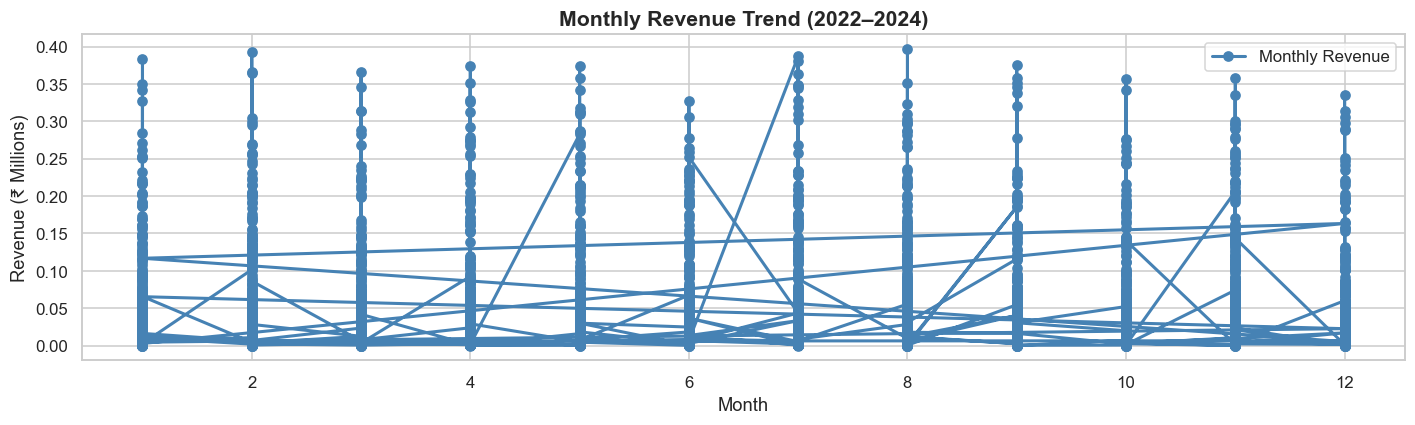

In [ ]:
# ──  Monthly Revenue Line Chart ───────────────────────
fig, ax = plt.subplots(figsize=(13, 4))

ax.plot(df['month'], df['total_price']/1e6,
        marker='o', linewidth=2, color='steelblue', label='Monthly Revenue')
ax.set_title('Monthly Revenue Trend (2022–2024)', fontsize=14, fontweight='bold')
ax.set_xlabel('Month')
ax.set_ylabel('Revenue (₹ Millions)')
ax.legend()
plt.tight_layout()
plt.savefig('plot_monthly_trend.png', dpi=120, bbox_inches='tight')
plt.show()

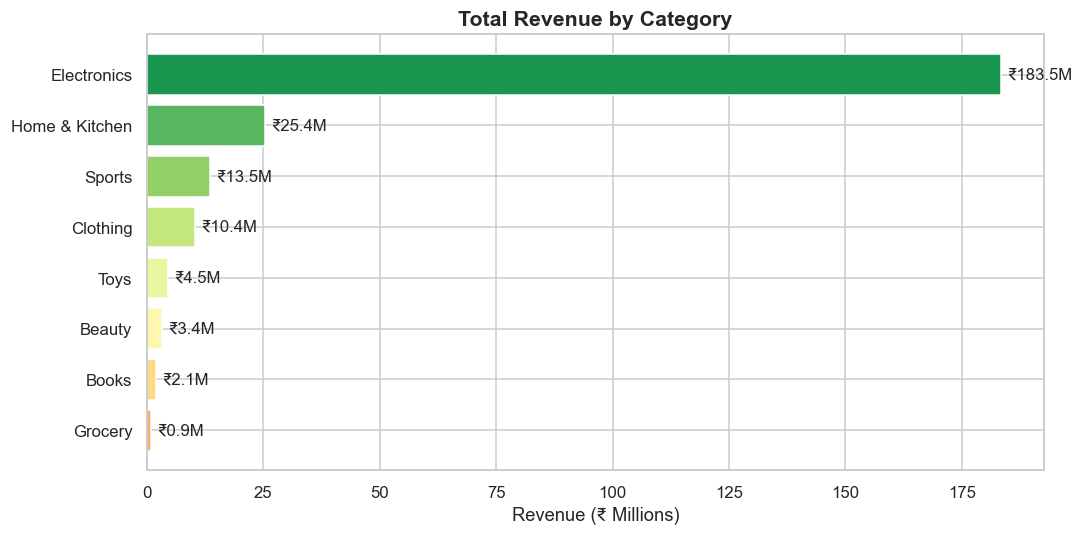

In [ ]:
# ──  Category Revenue Bar Chart ───────────────────────
fig, ax = plt.subplots(figsize=(10, 5))

cat_rev = df.groupby('category')['total_price'].sum().sort_values()

bars = ax.barh(cat_rev.index, cat_rev.values / 1e6, color=colors, edgecolor='white')
ax.bar_label(bars, labels=[f'₹{v/1e6:.1f}M' for v in cat_rev.values], padding=4)

ax.set_title('Total Revenue by Category', fontsize=14, fontweight='bold')
ax.set_xlabel('Revenue (₹ Millions)')
plt.tight_layout()
plt.savefig('plot_category_revenue.png', dpi=120, bbox_inches='tight')
plt.show()

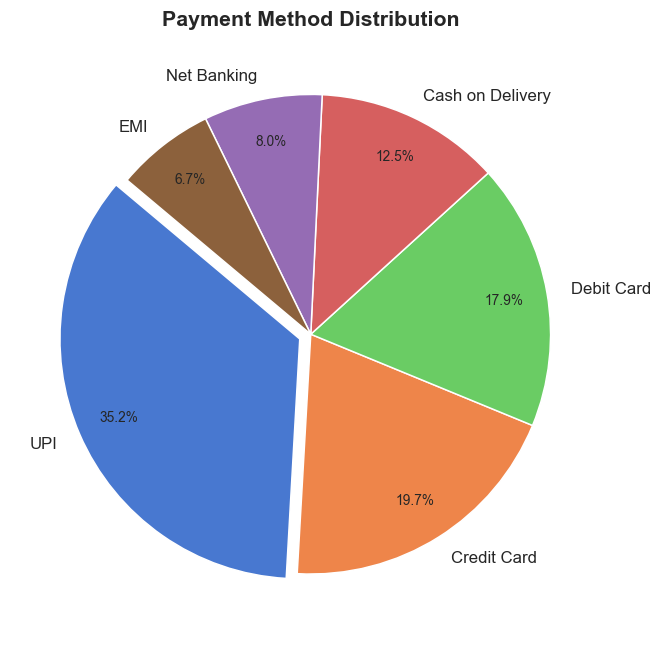

In [ ]:
# ──  Payment Method Pie Chart ─────────────────────────
fig, ax = plt.subplots(figsize=(7, 6))

pay_counts = df['payment_method'].value_counts()
explode = [0.05 if i==0 else 0 for i in range(len(pay_counts))]
wedges, texts, autotexts = ax.pie(
    pay_counts.values, labels=pay_counts.index,
    autopct='%1.1f%%', explode=explode,
    startangle=140, pctdistance=0.82
)
for at in autotexts:
    at.set_fontsize(9)

ax.set_title('Payment Method Distribution', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('plot_payment_pie.png', dpi=120, bbox_inches='tight')
plt.show()


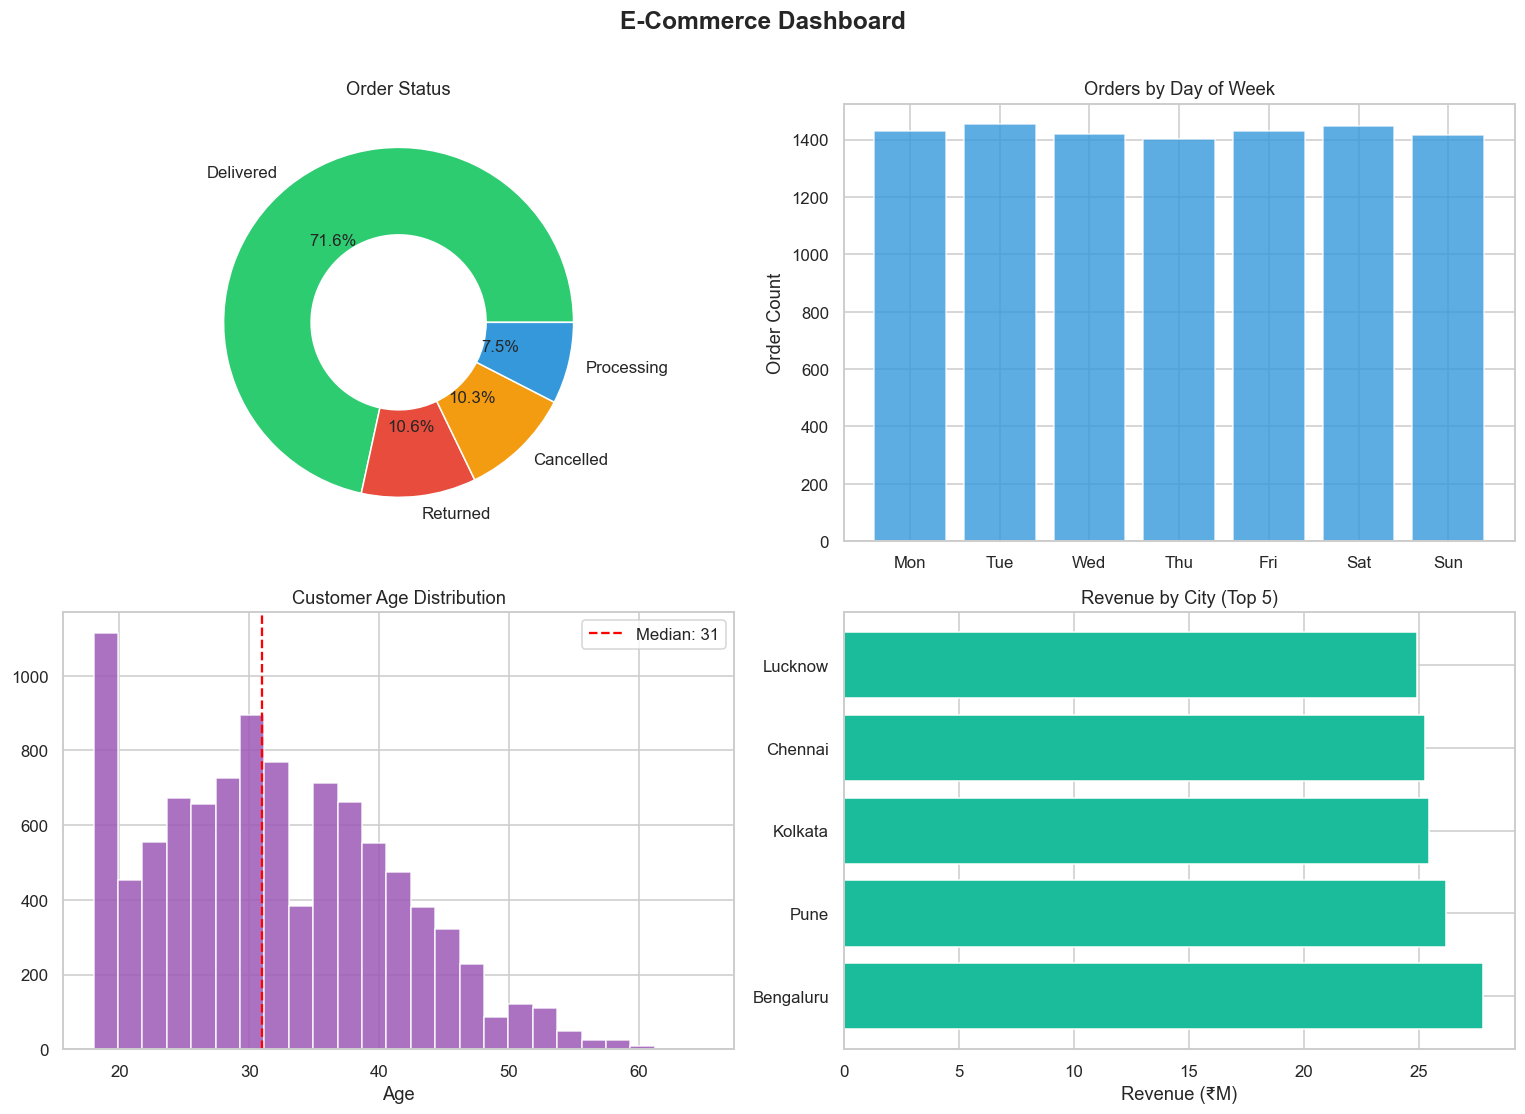

In [ ]:
# ──  Subplots Dashboard ───────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
fig.suptitle('E-Commerce Dashboard', fontsize=16, fontweight='bold', y=1.01)

# Top-left: Order status donut
status_counts = df['order_status'].value_counts()
colors_s = ['#2ecc71','#e74c3c','#f39c12','#3498db']
axes[0,0].pie(status_counts.values, labels=status_counts.index,
              autopct='%1.1f%%', colors=colors_s,
              wedgeprops=dict(width=0.5))
axes[0,0].set_title('Order Status')

# Top-right: Orders by day of week
dow_order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
dow_counts = df['day_of_week'].value_counts().reindex(dow_order)
axes[0,1].bar(range(7), dow_counts.values, color='#3498db', alpha=0.8)
axes[0,1].set_xticks(range(7))
axes[0,1].set_xticklabels(['Mon','Tue','Wed','Thu','Fri','Sat','Sun'])
axes[0,1].set_title('Orders by Day of Week')
axes[0,1].set_ylabel('Order Count')

# Bottom-left: Age distribution histogram
axes[1,0].hist(df['customer_age'].dropna(), bins=25, color='#9b59b6', edgecolor='white', alpha=0.85)
axes[1,0].axvline(df['customer_age'].median(), color='red', linestyle='--', label=f"Median: {df['customer_age'].median():.0f}")
axes[1,0].set_title('Customer Age Distribution')
axes[1,0].set_xlabel('Age')
axes[1,0].legend()

# Bottom-right: Top 5 cities
top_cities = df.groupby('customer_city')['total_price'].sum().nlargest(5)
axes[1,1].barh(top_cities.index, top_cities.values/1e6, color='#1abc9c')
axes[1,1].set_title('Revenue by City (Top 5)')
axes[1,1].set_xlabel('Revenue (₹M)')

plt.tight_layout()
plt.savefig('plot_dashboard.png', dpi=120, bbox_inches='tight')
plt.show()

### Seaborn Visualisations

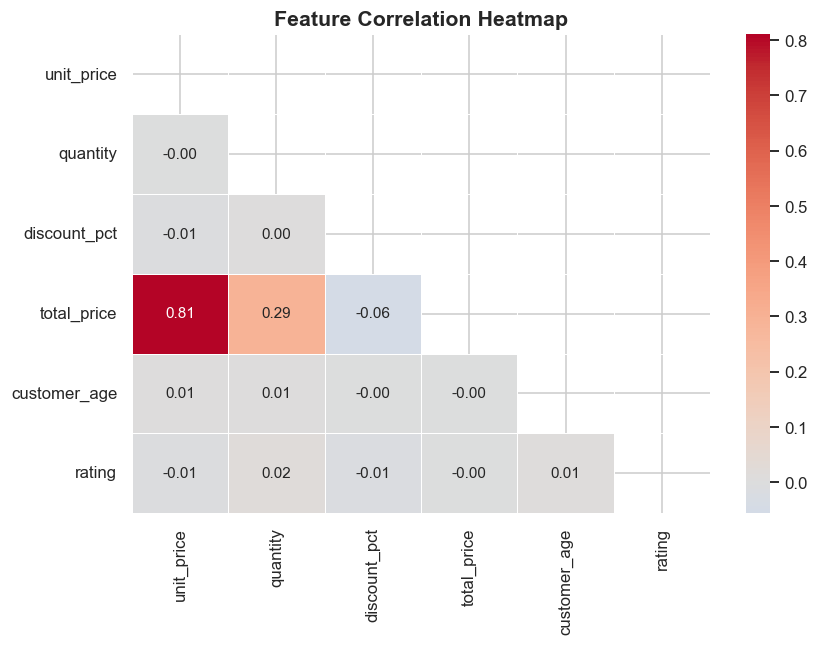

In [ ]:
# ──  Correlation Heatmap ──────────────────────────────
fig, ax = plt.subplots(figsize=(8, 6))

corr = df[['unit_price','quantity','discount_pct','total_price','customer_age','rating']].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))  # triu ==> upper triangle of an array

sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, linewidths=0.5, ax=ax, annot_kws={'size':10})
ax.set_title('Feature Correlation Heatmap', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('plot_heatmap.png', dpi=120, bbox_inches='tight')
plt.show()

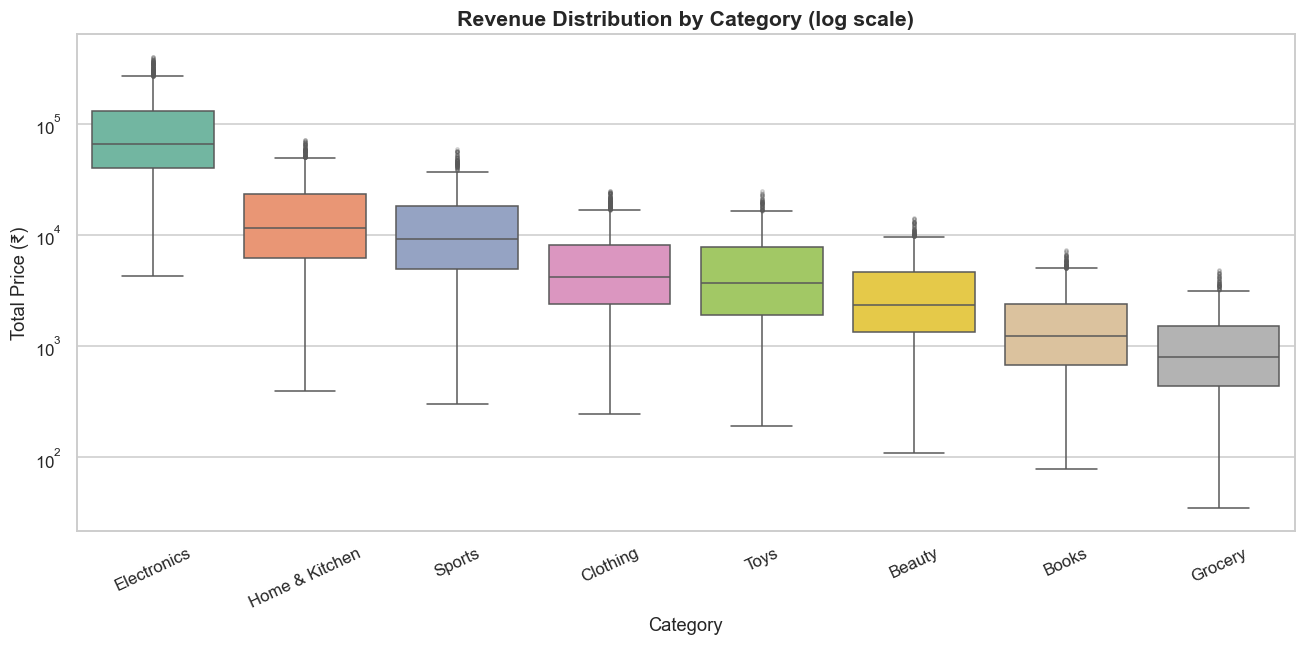

In [ ]:
# ──  Boxplot — Revenue by Category ───────────────────
fig, ax = plt.subplots(figsize=(12, 6))

order_cat = (df.groupby('category')['total_price']
               .median().sort_values(ascending=False).index.tolist())

sns.boxplot(data=df, x='category', y='total_price',
            order=order_cat, palette='Set2', ax=ax,
            flierprops={'marker':'o','markersize':2,'alpha':0.3})
ax.set_yscale('log')
ax.set_title('Revenue Distribution by Category (log scale)', fontsize=14, fontweight='bold')
ax.set_xlabel('Category')
ax.set_ylabel('Total Price (₹)')
ax.tick_params(axis='x', rotation=25)
plt.tight_layout()
plt.savefig('plot_boxplot.png', dpi=120, bbox_inches='tight')
plt.show()


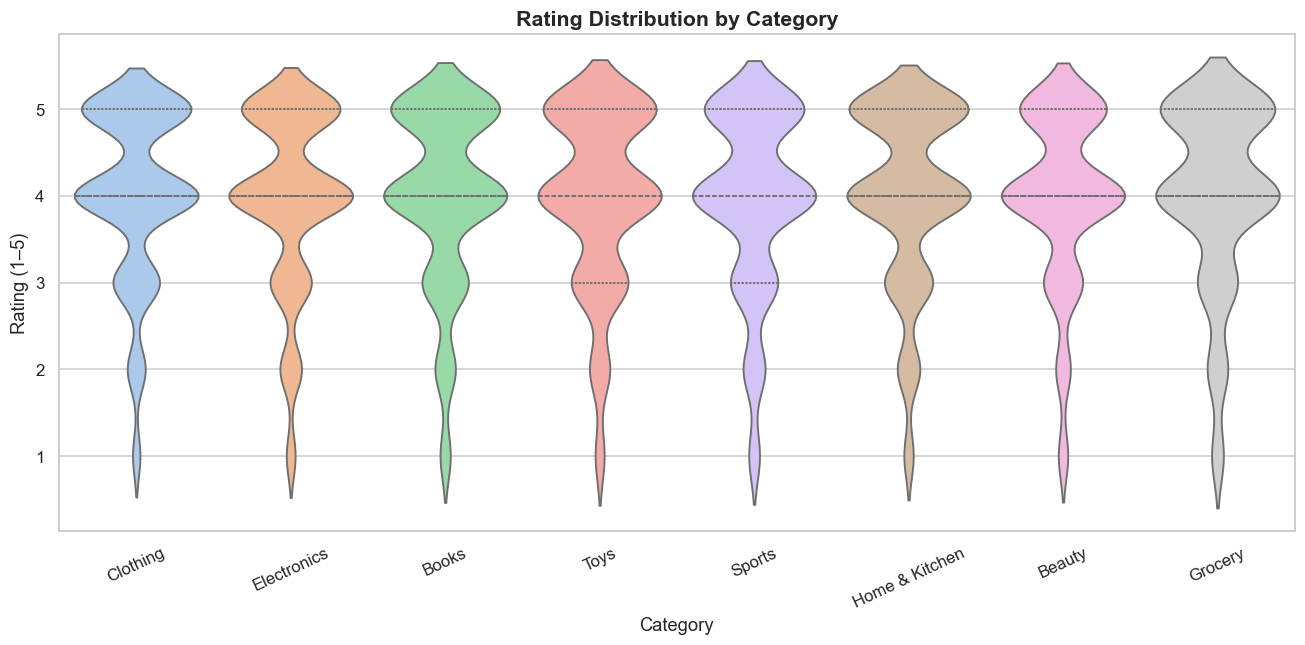

In [ ]:
# ──  Violin Plot — Rating by Category ─────────────────
delivered = df[df['order_status']=='Delivered'].dropna(subset=['rating'])

fig, ax = plt.subplots(figsize=(12, 6))
sns.violinplot(data=delivered, x='category', y='rating',
               palette='pastel', inner='quartile', ax=ax)
ax.set_title('Rating Distribution by Category', fontsize=14, fontweight='bold')
ax.set_xlabel('Category')
ax.set_ylabel('Rating (1–5)')
ax.tick_params(axis='x', rotation=25)
plt.tight_layout()
plt.savefig('plot_violin.png', dpi=120, bbox_inches='tight')
plt.show()

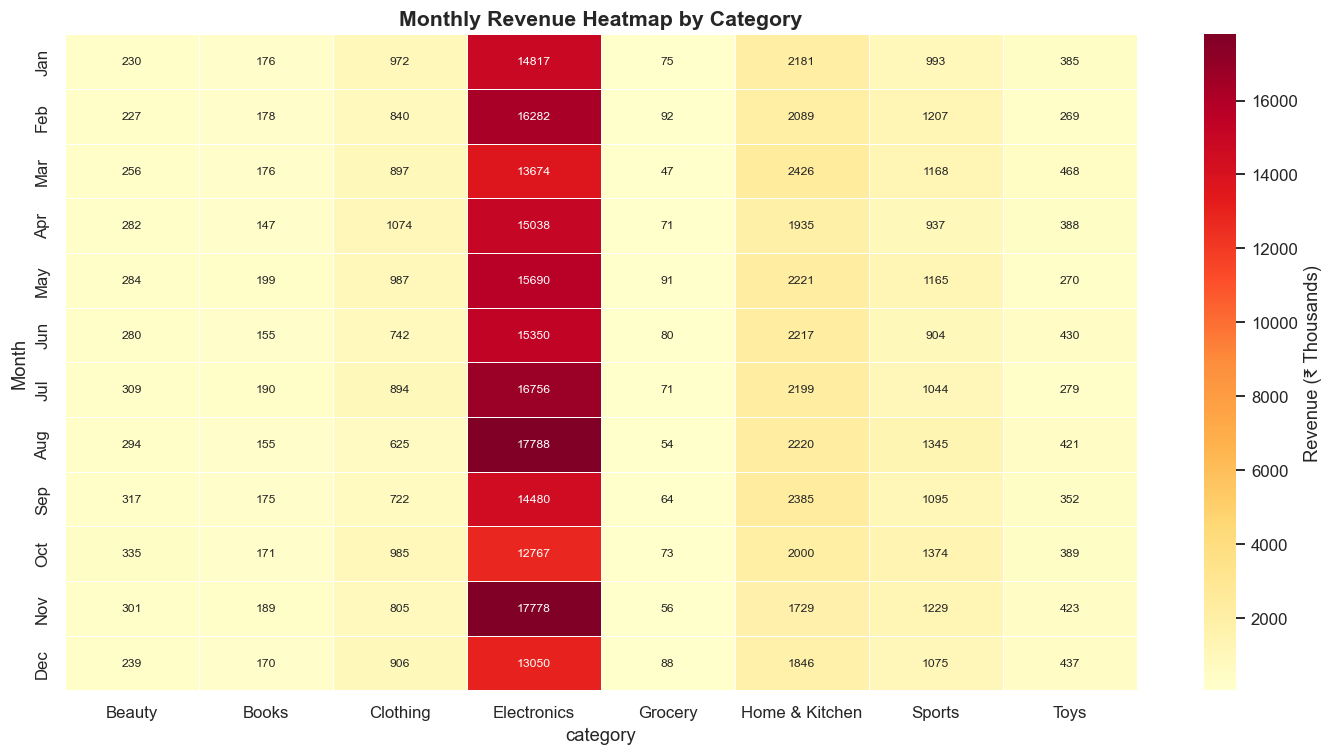

In [ ]:
# ──  Seaborn Heatmap — Revenue by Month × Category ────
pivot = df.pivot_table(values='total_price', index='month_name',
                       columns='category', aggfunc='sum')

month_order = ['Jan','Feb','Mar','Apr','May','Jun',
               'Jul','Aug','Sep','Oct','Nov','Dec']
pivot = pivot.reindex(month_order)

fig, ax = plt.subplots(figsize=(13, 7))
sns.heatmap(pivot/1e3, annot=True, fmt='.0f', cmap='YlOrRd',
            linewidths=0.4, ax=ax, annot_kws={'size':8},
            cbar_kws={'label':'Revenue (₹ Thousands)'})
ax.set_title('Monthly Revenue Heatmap by Category', fontsize=14, fontweight='bold')
ax.set_ylabel('Month')
plt.tight_layout()
plt.savefig('plot_monthly_heatmap.png', dpi=120, bbox_inches='tight')
plt.show()


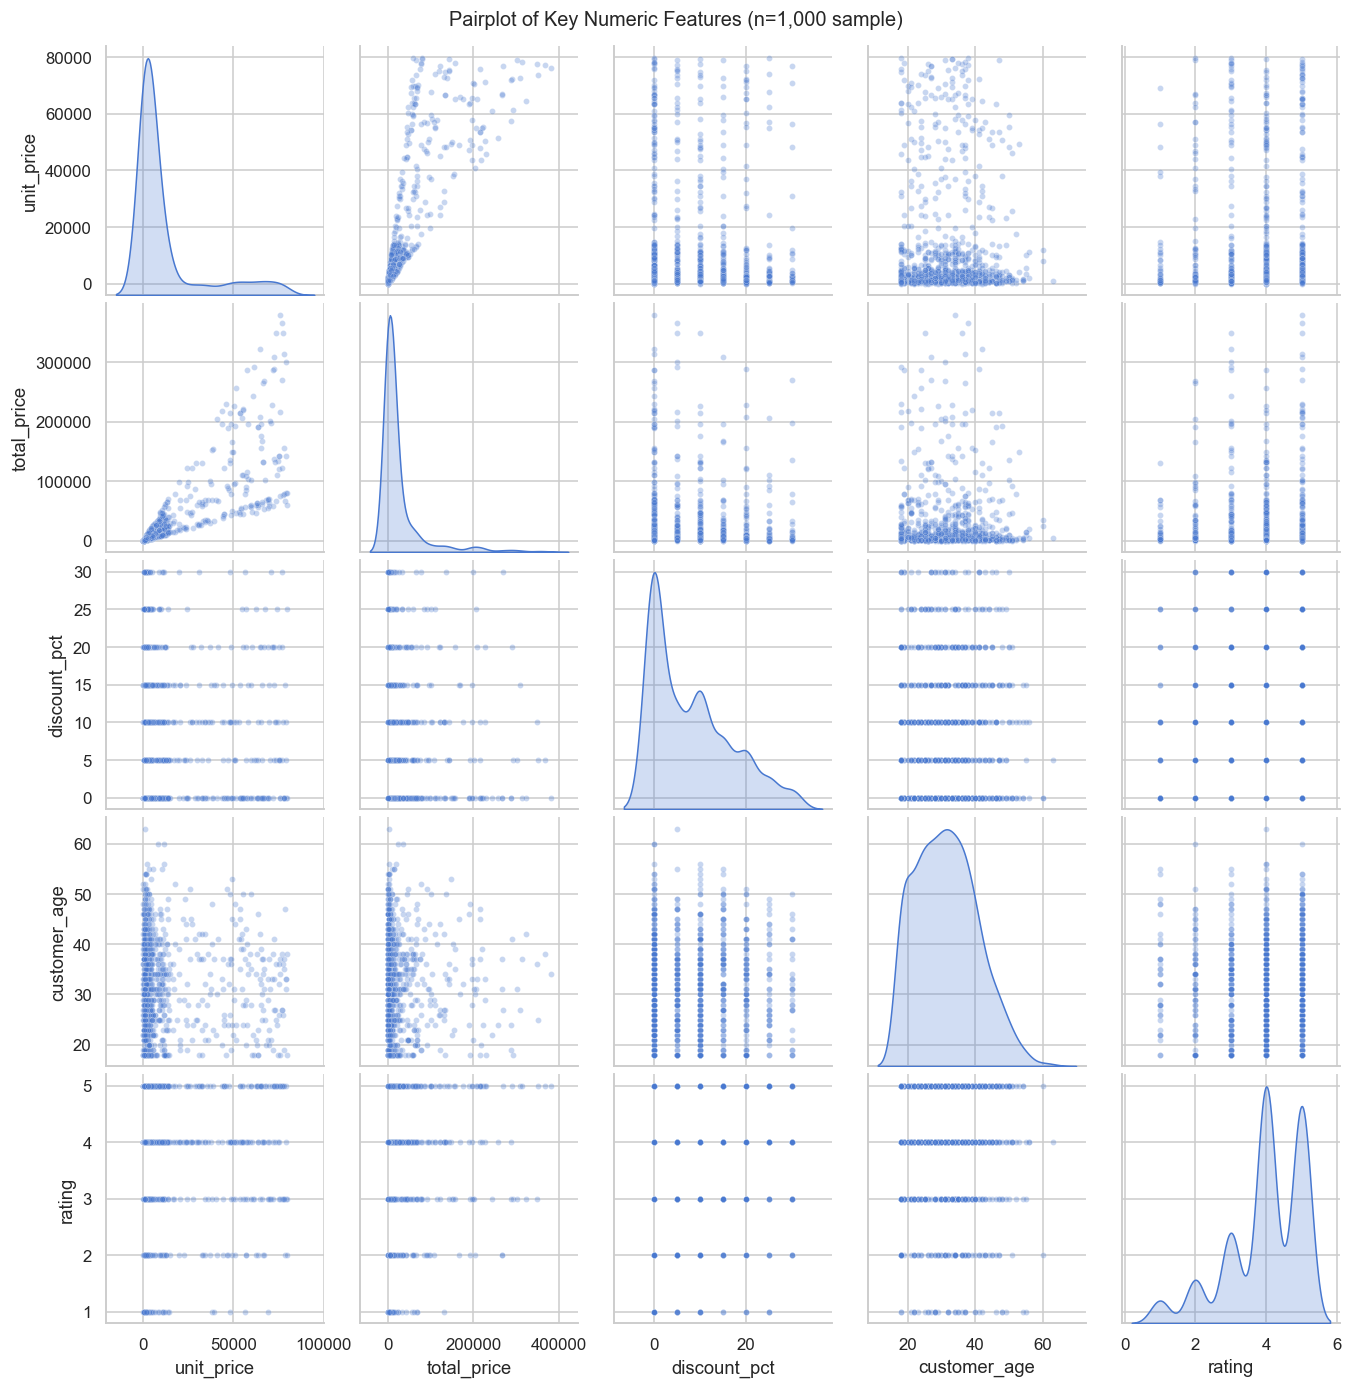

In [ ]:
# ──  Pairplot — Key Numeric Features ──────────────────
sample = df[['unit_price','total_price','discount_pct','customer_age','rating']].dropna().sample(1000, random_state=42)
g = sns.pairplot(sample, diag_kind='kde', plot_kws={'alpha':0.3,'s':15})
g.figure.suptitle('Pairplot of Key Numeric Features (n=1,000 sample)', y=1.01, fontsize=13)
plt.savefig('plot_pairplot.png', dpi=100, bbox_inches='tight')
plt.show()

### Business Insights & KPIs

In [ ]:
# ──  Key Performance Indicators ───────────────────────
delivered_df = df[df['order_status']=='Delivered']

kpis = {
    'Total Orders'          : len(df),
    'Delivered Orders'      : len(delivered_df),
    'Delivery Rate (%)'     : round(len(delivered_df)/len(df)*100, 2),
    'Total Revenue (₹)'     : round(delivered_df['total_price'].sum(), 2),
    'Avg Order Value (₹)'   : round(delivered_df['total_price'].mean(), 2),
    'Avg Rating'            : round(df['rating'].mean(), 2),
    'Avg Discount (%)'      : round(df['discount_pct'].mean(), 2),
    'Total Unique Customers': df['customer_id'].nunique(),
    'Return Rate (%)'       : round((df['order_status']=='Returned').sum()/len(df)*100, 2),
}

print("KEY PERFORMANCE INDICATORS")
print("=" * 45)
for k, v in kpis.items():
    print(f"  {k:<30}: {v:>12,}")


KEY PERFORMANCE INDICATORS
  Total Orders                  :       10,000
  Delivered Orders              :        7,158
  Delivery Rate (%)             :        71.58
  Total Revenue (₹)             : 174,728,706.4
  Avg Order Value (₹)           :    24,410.27
  Avg Rating                    :         3.98
  Avg Discount (%)              :         8.49
  Total Unique Customers        :        5,635
  Return Rate (%)               :        10.59


In [ ]:
# ──  Customer Segment Analysis ────────────────────────
seg_stats = (df.groupby('age_group')
               .agg(orders=('order_id','count'),
                    avg_spend=('total_price','mean'),
                    avg_discount=('discount_pct','mean'))
               .round(2))

print("\nCustomer Segment Analysis:")
print(seg_stats)



Customer Segment Analysis:
             orders  avg_spend  avg_discount
age_group                                   
Adult          5472   24117.23          8.47
Senior          352   25689.45          9.03
Young Adult    4176   24593.25          8.48


In [ ]:
# ──  Top Revenue Products ─────────────────────────────
top_products = (df.groupby(['category','product_name'])
                  .agg(orders=('order_id','count'),
                       revenue=('total_price','sum'))
                  .reset_index()
                  .sort_values('revenue', ascending=False)
                  .head(10))

top_products['revenue'] = top_products['revenue'].map('₹{:,.0f}'.format)
print("\nTop 10 Products by Revenue:")
print(top_products.to_string(index=False))



Top 10 Products by Revenue:
      category    product_name  orders     revenue
   Electronics              TV     262 ₹26,260,866
   Electronics      Headphones     250 ₹25,946,469
   Electronics         Speaker     252 ₹24,716,824
   Electronics     Smart Watch     262 ₹23,449,925
   Electronics          Laptop     227 ₹22,177,979
   Electronics      Smartphone     236 ₹21,187,627
   Electronics          Tablet     240 ₹21,122,032
   Electronics          Camera     219 ₹18,607,896
Home & Kitchen        Curtains     260  ₹4,690,952
Home & Kitchen Pressure Cooker     267  ₹4,493,444


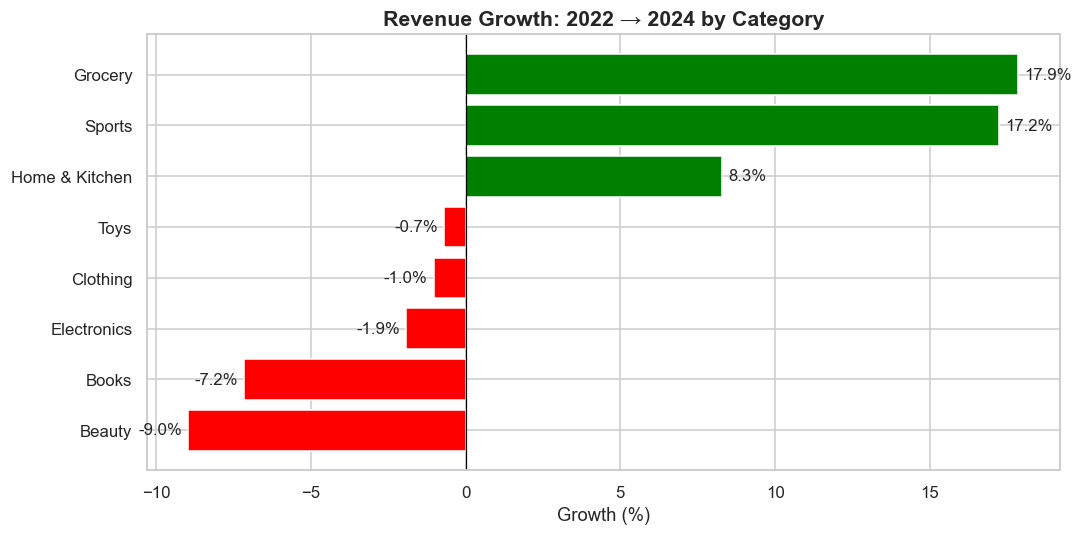

In [ ]:
# ──  Final Insights Chart — YoY Category Growth ───────
yoy = (df.groupby(['year','category'])['total_price']
         .sum().unstack().fillna(0))

growth = ((yoy.loc[2024] - yoy.loc[2022]) / yoy.loc[2022] * 100).sort_values()

fig, ax = plt.subplots(figsize=(10, 5))
colors = ['red' if v < 0 else 'green' for v in growth.values]
bars = ax.barh(growth.index, growth.values, color=colors, edgecolor='white')
ax.bar_label(bars, labels=[f'{v:.1f}%' for v in growth.values], padding=4)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_title('Revenue Growth: 2022 → 2024 by Category', fontsize=14, fontweight='bold')
ax.set_xlabel('Growth (%)')
plt.tight_layout()
plt.savefig('plot_yoy_growth.png', dpi=120, bbox_inches='tight')
plt.show()
